Wczytywanie danych...
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


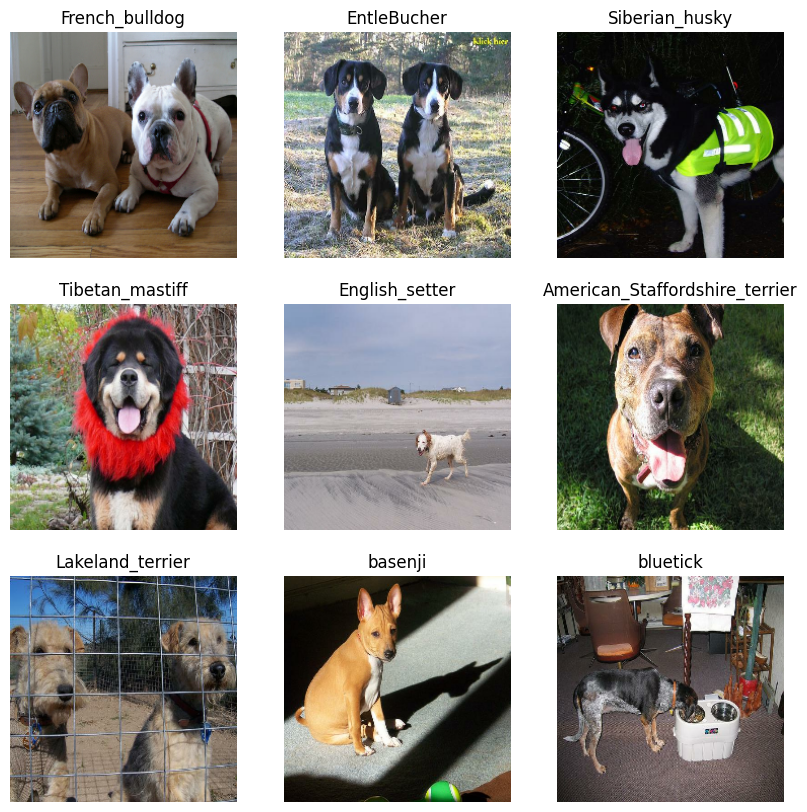

Budowanie modelu...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Rozpoczęcie treningu (to może chwilę potrwać)...
Epoch 1/3
515/515 ━━━━━━━━━━━━━━━━━━━━ 85s 161ms/step - accuracy: 0.7269 - loss: 1.0610 - val_accuracy: 0.8175 - val_loss: 0.5845
Epoch 2/3
515/515 ━━━━━━━━━━━━━━━━━━━━ 81s 157ms/step - accuracy: 0.8880 - loss: 0.3732 - val_accuracy: 0.8246 - val_loss: 0.5432
Epoch 3/3
515/515 ━━━━━━━━━━━━━━━━━━━━ 80s 155ms/step - accuracy: 0.9365 - loss: 0.2414 - val_accuracy: 0.8268 - val_loss: 0.5366
129/129 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.8268 - loss: 0.5366
\nDokładność modelu (Accuracy) na zbiorze testowym: 82.68%


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Ustawienia i Preprocessing
IMG_SIZE = (224, 224) # Zmieniamy rozmiar każdego zdjęcia na 224x224 piksele
BATCH_SIZE = 32
DATA_DIR = 'data/Images' # Ścieżka do Twoich wypakowanych zdjęć

print("Wczytywanie danych...")
# Wczytanie zbioru treningowego (80% zdjęć)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Wczytanie zbioru walidacyjnego/testowego (20% zdjęć)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

# 2. EDA - Wyświetlenie przykładowych danych
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]].split('-')[-1]) # Wyciągamy samą nazwę rasy z folderu
        plt.axis("off")
plt.show()

# 3. Trening Modelu Bazowego
print("Budowanie modelu...")
# Pobieramy gotowy, lekki model bez ostatniej warstwy
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Zamrażamy jego wiedzę

# Dodajemy własne warstwy dopasowane do naszych ras psów
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs) # Normalizacja pikseli
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Rozpoczęcie treningu (to może chwilę potrwać)...")
# Trenujemy na razie tylko przez 3 epoki (fazy), żeby było szybko
history = model.fit(train_dataset, validation_data=val_dataset, epochs=3)

# 4. Ewaluacja
loss, accuracy = model.evaluate(val_dataset)
print(f"\\nDokładność modelu (Accuracy) na zbiorze testowym: {accuracy * 100:.2f}%")

In [2]:
model.save('dog_baseline_model.keras')
print("Model zapisany!")

Model zapisany!
